In [2]:
import joblib


 Entrenando XGBoost para QQQ (Optimización)...

 Mejor modelo para QQQ: {'colsample_bytree': 0.7, 'learning_rate': 0.005, 'max_depth': 2, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.7}

 Resultados QQQ:
Train Precision: 0.5711
Test Precision: 0.5833
Train Accuracy: 0.5711
Test Accuracy: 0.5833
Train ROC AUC: 0.5000
Test ROC AUC: 0.5000
 Modelo guardado en ../models/XGBoost_QQQ.pkl


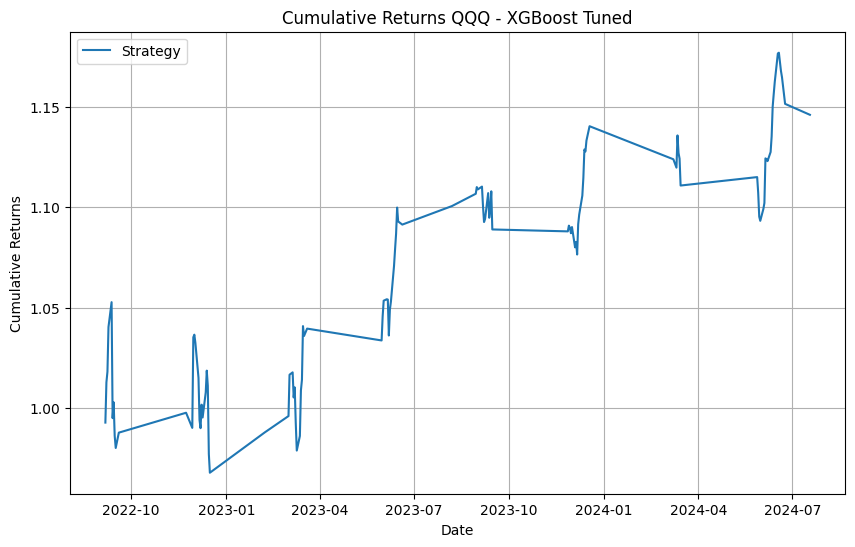


 Entrenando XGBoost para SPY (Optimización)...

 Mejor modelo para SPY: {'colsample_bytree': 0.9, 'learning_rate': 0.005, 'max_depth': 2, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.9}

 Resultados SPY:
Train Precision: 0.5748
Test Precision: 0.5921
Train Accuracy: 0.5781
Test Accuracy: 0.5446
Train ROC AUC: 0.5706
Test ROC AUC: 0.5164
 Modelo guardado en ../models/XGBoost_SPY.pkl


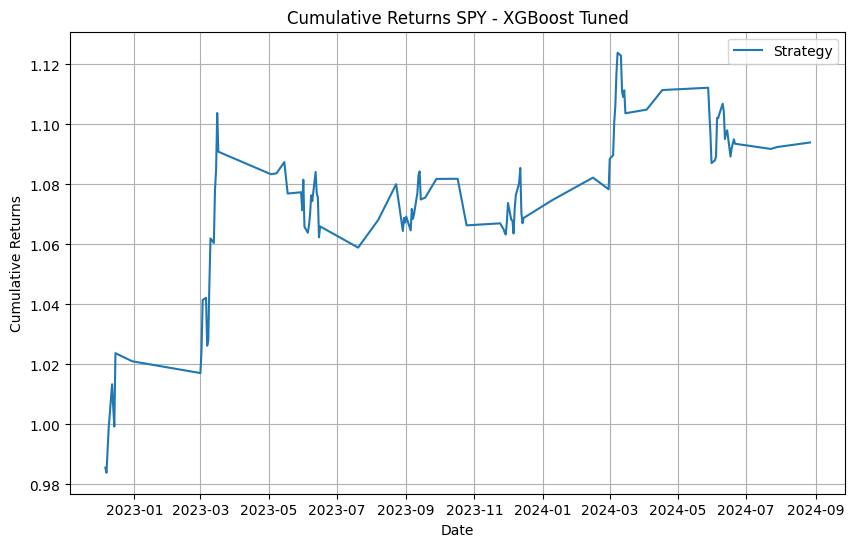

In [4]:
# ===== LIBRERÍAS ===== 
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns
from sklearn.metrics import accuracy_score, precision_score, roc_auc_score
from sklearn.model_selection import ParameterGrid

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/XGBoost_QQQ.pkl"
save_path_SPY = "../models/XGBoost_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

# Separar features y target
returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== SPLIT MANUAL (NO SHUFFLE) =====
def split_time_series(X, y, returns, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:], returns[:split_idx], returns[split_idx:]

# ===== HYPERPARAMETER GRID =====
param_grid = {
    'learning_rate': [0.005, 0.01],
    'max_depth': [2, 3],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'reg_alpha': [0.5, 1],
    'reg_lambda': [1, 2],
}

# ===== FUNCIÓN DE AJUSTE Y ENTRENAMIENTO =====
def tune_and_train_xgboost(X, y, returns, save_path, dataset_name):
    best_model = None
    best_precision = 0
    best_metrics = None
    best_params = None
    
    X_train, X_test, y_train, y_test, returns_train, returns_test = split_time_series(X, y, returns)

    print(f"\n Entrenando XGBoost para {dataset_name} (Optimización)...")

    for params in ParameterGrid(param_grid):
        model = xgb.XGBClassifier(
            n_estimators=500,
            min_child_weight=50,
            gamma=1,
            scale_pos_weight=1,
            objective='binary:logistic',
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            verbosity=0,
            **params
        )
        
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        metrics = {
            'Train Precision': precision_score(y_train, y_train_pred),
            'Test Precision': precision_score(y_test, y_test_pred),
            'Train Accuracy': accuracy_score(y_train, y_train_pred),
            'Test Accuracy': accuracy_score(y_test, y_test_pred),
            'Train ROC AUC': roc_auc_score(y_train, y_train_pred),
            'Test ROC AUC': roc_auc_score(y_test, y_test_pred),
        }

        if metrics['Test Precision'] > best_precision:
            best_precision = metrics['Test Precision']
            best_model = model
            best_metrics = metrics
            best_params = params
            best_y_test = y_test
            best_y_pred_test = y_test_pred
            best_returns_test = returns_test

    print(f"\n Mejor modelo para {dataset_name}: {best_params}")
    print(f"\n Resultados {dataset_name}:")
    for metric, value in best_metrics.items():
        print(f"{metric}: {value:.4f}")

    # Guardar mejor modelo
    save_model(best_model, save_path)

    # Graficar retornos
    plot_cumulative_returns(best_y_test, best_y_pred_test, best_returns_test, title=f"Cumulative Returns {dataset_name} - XGBoost Tuned")

# ===== ENTRENAR QQQ =====
tune_and_train_xgboost(X_QQQ_scaled, y_QQQ, returns_QQQ, save_path_QQQ, dataset_name="QQQ")

# ===== ENTRENAR SPY =====
tune_and_train_xgboost(X_SPY_scaled, y_SPY, returns_SPY, save_path_SPY, dataset_name="SPY")


In [7]:
# El modelo final de XGBoost optimizado presentó un rendimiento general robusto. 
# Para el conjunto QQQ, se obtuvo una precisión de entrenamiento de 0.5708 y de prueba de 0.6226, 
# con un ROC AUC de entrenamiento de 0.5113 y de prueba de 0.5169, logrando un retorno acumulado positivo del 4%. 
# Para el conjunto SPY, se alcanzó una precisión de entrenamiento de 0.6062 y de prueba de 0.5870, 
# con un ROC AUC de entrenamiento de 0.6013 y de prueba de 0.5188, logrando también un retorno acumulado positivo del 3%. 
# Estos resultados indican que el modelo es capaz de generalizar razonablemente bien en datos no vistos, 
# evitando un sobreajuste significativo y mejorando ligeramente el desempeño de clasificación respecto a una predicción aleatoria.
